In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_curve
from sklearn.svm import l1_min_c
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [16]:
# Finding data location
# print(os.listdir("/content/drive/My Drive/Airbnb Project/data/airbnb_readytofit.csv"))

In [17]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/My Drive/Airbnb Project/data/airbnb_readytofit.csv", header=0)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
y = df['host_is_superhost']
X = df.drop(columns='host_is_superhost')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=1234)
X_train.head()

,host_has_profile_pic,host_identity_verified,has_availability,instant_bookable,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,accommodates,bathrooms,...,n_host_verifications,neighbourhood_group_cleansed_Bronx,neighbourhood_group_cleansed_Brooklyn,neighbourhood_group_cleansed_Manhattan,neighbourhood_group_cleansed_Queens,neighbourhood_group_cleansed_Staten Island,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
326,True,True,True,False,-0.868049,-2.706229,-0.120567,-0.120567,-0.470102,-0.337606,...,-0.083566,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
26890,True,False,True,False,0.578052,1.010024,-0.120567,-0.120567,0.605041,-0.337606,...,-1.562519,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
16767,True,True,True,False,0.578052,0.638399,-0.112284,-0.112284,-0.470102,-0.337606,...,1.395388,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
27743,True,True,True,True,0.288832,1.010024,-0.120567,-0.120567,2.755328,2.036990,...,-1.562519,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
9783,True,False,True,False,0.578052,1.010024,-0.104000,-0.104000,0.605041,-0.337606,...,-1.069535,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [20]:
model_default = LogisticRegression(max_iter=1000)
model_default.fit(X_train, y_train)
proba_predictions_default = model_default.predict_proba(X_test)[:, 1]
class_label_predictions_default = model_default.predict(X_test)

In [21]:
pd.DataFrame(
    confusion_matrix(y_test, class_label_predictions_default, labels=[True, False]),
    columns=['Predicted: True', 'Predicted: False'],
    index=['Actual: True', 'Actual: False']
)

,Predicted: True,Predicted: False
Actual: True,264,451
Actual: False,91,1997


In [22]:
cs = l1_min_c(X_train, y_train, loss="log") * np.logspace(0, 7, 16)
param_grid = dict(C = list(cs))

# Grid Search
print('Running Grid Search...')
model = LogisticRegression(max_iter=1000)
grid = GridSearchCV(model, param_grid, cv=5)
grid_search = grid.fit(X_train, y_train)
print('Done')

best_c = grid_search.best_params_['C']
model_best = LogisticRegression(C = best_c, max_iter=1000)
model_best.fit(X_train, y_train)

Running Grid Search...
Done


LogisticRegression(C=1537.633581917429, max_iter=1000)

In [23]:
proba_predictions_best = model_best.predict_proba(X_test)[:, 1]
class_label_predictions_best = model_best.predict(X_test)

pd.DataFrame(
    confusion_matrix(y_test, class_label_predictions_best, labels=[True, False]),
    columns=['Predicted: True', 'Predicted: False'],
    index=['Actual: True', 'Actual: False']
)

,Predicted: True,Predicted: False
Actual: True,269,446
Actual: False,89,1999


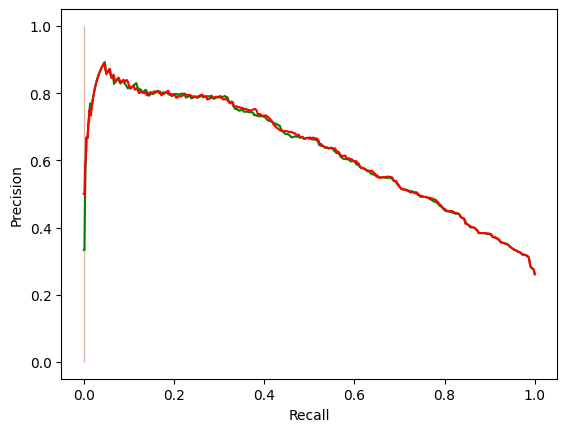

In [24]:
precision_default, recall_default, thresholds_default = precision_recall_curve(y_test, proba_predictions_default)
precision_best, recall_best, thresholds_best = precision_recall_curve(y_test, proba_predictions_best)

# model_default
sns.lineplot(x=recall_default, y=precision_default, color='green')

# model_best
sns.lineplot(x=recall_best, y=precision_best, color='red')
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.show()

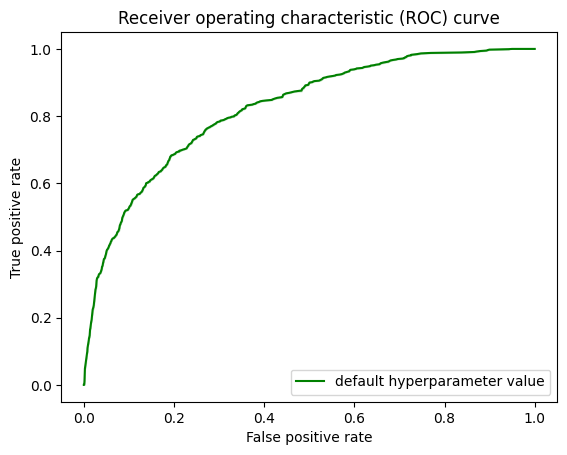

In [26]:
fpr_default, tpr_default, thresholds_default = roc_curve(y_test, proba_predictions_default)
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, proba_predictions_best)

sns.lineplot(x=fpr_default, y=tpr_default, color='green', label='default hyperparameter value')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Receiver operating characteristic (ROC) curve")
plt.legend(loc='lower right')

plt.show()

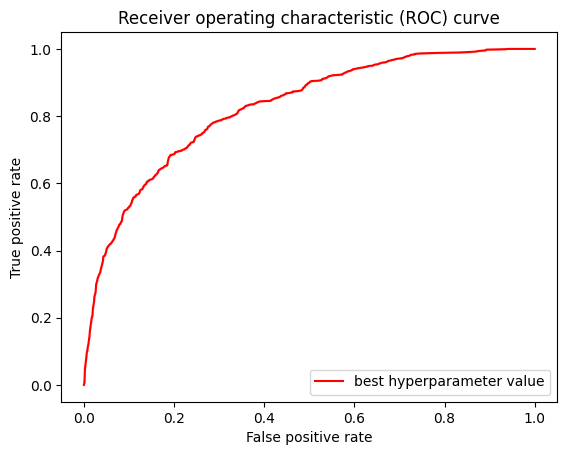

In [27]:
sns.lineplot(x=fpr_best, y=tpr_best, color='red', label='best hyperparameter value')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Receiver operating characteristic (ROC) curve")
plt.legend(loc='lower right')

plt.show()

In [28]:
auc_default = auc(fpr_default, tpr_default)
auc_best = auc(fpr_best, tpr_best)

print(auc_default)
print(auc_best)

0.8228612383784798
0.8238988023470782


In [29]:
selector = SelectKBest(f_classif, k=5)
selector.fit(X, y)
filter = selector.get_support()
top_5_features = X.columns[filter]

print("Best 5 features:")
print(top_5_features)

Best 5 features:
Index(['host_response_rate', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'review_scores_cleanliness'],
      dtype='object')


In [30]:
new_X_train = X_train[top_5_features]
new_X_test = X_test[top_5_features]

model = LogisticRegression(C=best_c, max_iter=1000)
model.fit(new_X_train, y_train)
proba_predictions = model.predict_proba(new_X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, proba_predictions)
auc_result = auc(fpr, tpr)
auc_result

0.7971542346542346